# Wedge Product  

## Introduction

Never once in my life I imagine I would learn geometric algebra conciously. Not because I despise the pure mathematics branch, but I feel insecure on the topic (to be fair I got a C in my Introduction to Real Analysis class). But here we are. So we will discuss the wedge product and how it can be useful. 

There is this [article](https://substack.com/@agussudjianto/p-184606453) wrote by Agus Sudjianto that I can't imagine. So we will plot the code and try to really understand the mathematics behind it.

## Code

Below is the code given and we will disect the code by parts.

In [1]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# 1. Generate Data: Parabola with Geometric Noise
np.random.seed(42)
N = 1000
t = np.linspace(-2, 2, N)
x_clean = t
y_clean = t**2

# Add noise geometrically (orthogonal to the curve)
noise_mag = 0.3
angle = np.random.uniform(0, 2*np.pi, N)
x = x_clean + noise_mag * np.cos(angle)
y = y_clean + noise_mag * np.sin(angle)

# --- Test 1: Standard Additive Noise Model (ANM) ---
# Hypothesis: Y = f(X) + Noise
# We fit the curve and check if residuals are independent of X
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(x.reshape(-1, 1))
model = LinearRegression().fit(X_poly, y)
y_pred = model.predict(X_poly)

residuals = y - y_pred
# Correlation between |Residuals| and X
# If ANM works, this should be close to 0.
anm_correlation = np.corrcoef(np.abs(residuals), np.abs(x))[0, 1]


# --- Test 2: Geometric Volume Comparison ---
def calculate_volume_instability(cause, effect, num_bins=20):
    """
    Splits data into local patches based on the 'cause'.
    Measures the stability (std/mean) of the Wedge Volume (Determinant).
    """
    # Sort by the candidate cause
    idx = np.argsort(cause)
    c_sorted = cause[idx]
    e_sorted = effect[idx]
    
    chunks_c = np.array_split(c_sorted, num_bins)
    chunks_e = np.array_split(e_sorted, num_bins)
    
    volumes = []
    for cc, ce in zip(chunks_c, chunks_e):
        if len(cc) > 5:
            # Create local matrix [Cause, Effect]
            local_data = np.column_stack([cc, ce])
            # Compute Covariance and Determinant (Volume^2)
            cov = np.cov(local_data, rowvar=False)
            vol = np.linalg.det(cov)
            volumes.append(vol)
            
    # Return coefficient of variation (lower is more stable)
    return np.std(volumes) / np.mean(volumes)

geo_score_xy = calculate_volume_instability(x, y)
geo_score_yx = calculate_volume_instability(y, x)

print(f"--- ANM Test (Standard) ---")
print(f"Residual Correlation: {anm_correlation:.3f}")
if anm_correlation > 0.1:
    print("Verdict: FAILURE. Rejects true cause due to heteroscedasticity.")
else:
    print("Verdict: SUCCESS.")

print(f"\n--- Geometric Volume Test ---")
print(f"Instability (X -> Y): {geo_score_xy:.3f}")
print(f"Instability (Y -> X): {geo_score_yx:.3f}")
if geo_score_xy < geo_score_yx:
    print("Verdict: SUCCESS. Correctly identifies X -> Y as the stable geometry.")
else:
    print("Verdict: FAILURE.")


--- ANM Test (Standard) ---
Residual Correlation: 0.498
Verdict: FAILURE. Rejects true cause due to heteroscedasticity.

--- Geometric Volume Test ---
Instability (X -> Y): 1.016
Instability (Y -> X): 1.756
Verdict: SUCCESS. Correctly identifies X -> Y as the stable geometry.


## How the Data Looks like

Okay so apparently that the clean data is just a thick parabola curves and we perturbed the data by introducing 'noise' to the data. What interesting is the residuals which for some reason looks like a bowtie... And the residuals correlation is almost 0.5 which kind of visible in our plot. 

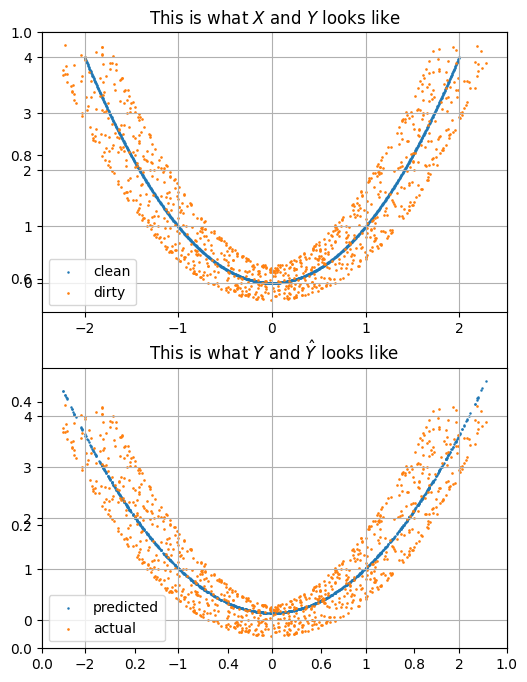

In [2]:
import matplotlib.pyplot as plt

plt.subplots(figsize=(6, 8))

plt.subplot(2,1,1)
plt.scatter(x_clean, y_clean, label = 'clean', s = 0.6)
plt.scatter(x, y, label = 'dirty', s = 0.8)
plt.title('This is what $X$ and $Y$ looks like')
plt.legend()
plt.grid()

plt.subplot(2,1,2)
plt.scatter(x, y_pred, label = 'predicted', s = 0.6)
plt.scatter(x, y, label = 'actual', s = 0.8)
plt.title('This is what $Y$ and $\\hat{Y}$ looks like')
plt.legend()
plt.grid()
plt.show()

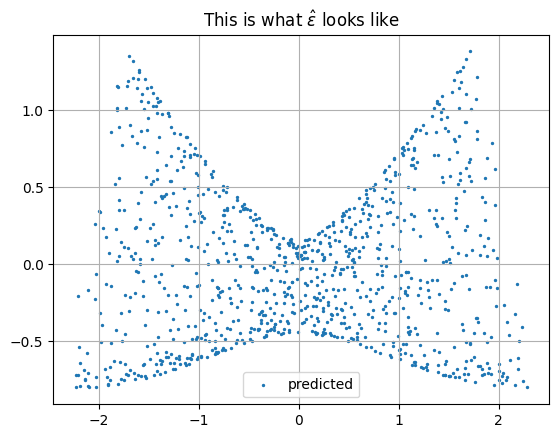

In [3]:
plt.scatter(x, residuals, label = 'predicted', s = 2)
plt.title('This is what $\\hat{\\epsilon}$ looks like')
plt.legend()
plt.grid()
plt.show()